# VisHeart RV 4D Reconstruction

This notebook builds a patient-specific RV cavity mesh sequence from a VisHeart segmentation NIfTI. It uses the production label convention (`RV = 1`) and preserves physical coordinates through the NIfTI affine.

This is an isolated geometric baseline for teammate handoff. It does not edit the VisHeart system and does not assume the existing LV DeepSDF checkpoint is valid for RV.

## Install once

From the prototype folder run `py -m pip install -r requirements.txt`. Restart the kernel after installation if the notebook was already open.

In [52]:
from pathlib import Path
import json
import numpy as np
import nibabel as nib
from scipy import ndimage
from skimage.measure import marching_cubes

# Add further local NIfTI paths here for cross-patient validation.
MASK_PATH = Path(r'C:\Users\CAT\Downloads\002_SA_ES_segmentation.nii.gz')
MASK_PATHS = [MASK_PATH]
OUTPUT_DIR = Path(r'E:\Jy\visheart-rv-4d-notebook\outputs')
RV_LABEL = 1
MARCHING_CUBES_LEVEL = 0.5
MIN_COMPONENT_VOXELS = 32
SMOOTHING_ITERATIONS = 1
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [53]:
def load_mask(path: Path, label: int = RV_LABEL):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Mask not found: {path}')
    image = nib.load(str(path))
    raw = np.asarray(image.dataobj)
    if raw.ndim not in (3, 4):
        raise ValueError(f'Expected a 3D or 4D mask, got shape {raw.shape}')
    frames = raw[..., None] if raw.ndim == 3 else raw
    rv = np.isclose(frames, label)
    if not np.any(rv):
        labels = np.unique(raw)
        raise ValueError(f'RV label {label} is absent. Labels found: {labels[:30]}')
    return image, rv, np.asarray(image.affine, dtype=float)

image, rv_frames, affine = load_mask(MASK_PATH)
print({'mask': str(MASK_PATH), 'shape_xyz_t': rv_frames.shape, 'voxel_sizes_mm': image.header.get_zooms()[:3], 'frames_with_rv': int(np.sum(np.any(rv_frames, axis=(0, 1, 2))))})

{'mask': 'C:\\Users\\CAT\\Downloads\\002_SA_ES_segmentation.nii.gz', 'shape_xyz_t': (256, 256, 7, 1), 'voxel_sizes_mm': (np.float32(1.4844004), np.float32(1.4844003), np.float32(9.999987)), 'frames_with_rv': 1}


## Prepare the RV volume

Small isolated components are removed per frame. This is conservative cleanup for segmentation noise, not a learned correction.

In [54]:
def keep_main_component(mask: np.ndarray, minimum_voxels: int = MIN_COMPONENT_VOXELS) -> np.ndarray:
    labels, count = ndimage.label(mask)
    if count == 0:
        return mask.astype(bool)
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0
    main_label = int(np.argmax(sizes))
    if sizes[main_label] < minimum_voxels:
        return np.zeros_like(mask, dtype=bool)
    return labels == main_label

def prepare_frames(rv: np.ndarray) -> list[np.ndarray]:
    prepared = []
    for frame_index in range(rv.shape[3]):
        mask = keep_main_component(rv[..., frame_index])
        for _ in range(SMOOTHING_ITERATIONS):
            mask = ndimage.binary_closing(mask, iterations=1)
        prepared.append(mask)
    return prepared

prepared_frames = prepare_frames(rv_frames)
frame_voxels = [int(frame.sum()) for frame in prepared_frames]
print({'frame_count': len(prepared_frames), 'rv_voxels_per_frame': frame_voxels})

{'frame_count': 1, 'rv_voxels_per_frame': [1668]}


In [55]:
def voxel_to_world(vertices: np.ndarray, affine: np.ndarray) -> np.ndarray:
    homogeneous = np.c_[vertices, np.ones(len(vertices))]
    return (homogeneous @ affine.T)[:, :3]

def frame_mesh(mask: np.ndarray, affine: np.ndarray) -> dict:
    if mask.sum() < 8:
        raise ValueError('RV mask is too small to generate a surface')
    vertices, faces, normals, values = marching_cubes(mask.astype(np.float32), level=MARCHING_CUBES_LEVEL)
    return {
        'vertices': voxel_to_world(vertices, affine),
        'faces': faces.astype(np.int64),
        'normals': normals,
        'voxel_count': int(mask.sum()),
    }

meshes = []
for frame_index, mask in enumerate(prepared_frames):
    if mask.sum() == 0:
        print(f'Skipping frame {frame_index}: no RV voxels')
        meshes.append(None)
        continue
    mesh = frame_mesh(mask, affine)
    mesh['frame_index'] = frame_index
    meshes.append(mesh)
    print(f'frame {frame_index:02d}: {len(mesh["vertices"]):,} vertices, {len(mesh["faces"]):,} triangles')

frame 00: 2,073 vertices, 4,146 triangles


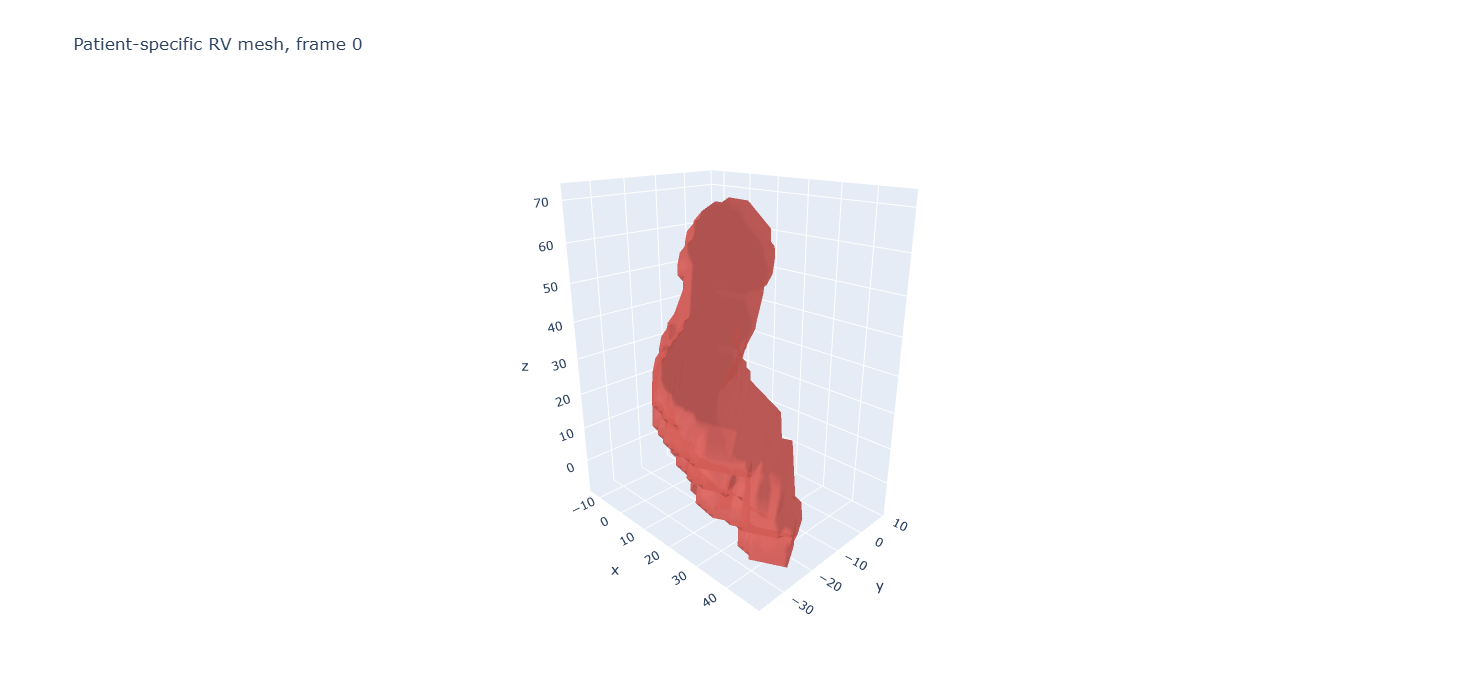

In [56]:
# Notebook-native 3D view. An HTML viewer is not required.
import plotly.graph_objects as go

valid_meshes = [mesh for mesh in meshes if mesh is not None]
if not valid_meshes:
    raise RuntimeError('No valid RV meshes were generated')

def mesh_trace(mesh: dict) -> go.Mesh3d:
    vertices, faces = mesh['vertices'], mesh['faces']
    return go.Mesh3d(x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2], i=faces[:, 0], j=faces[:, 1], k=faces[:, 2], opacity=0.78, color='#d95f59', flatshading=False, name=f'frame {mesh["frame_index"]:02d}')

fig = go.Figure(data=[mesh_trace(valid_meshes[0])])
fig.update_layout(title='Patient-specific RV mesh, frame 0', scene=dict(aspectmode='data', camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9), up=dict(x=0, y=0, z=1))), width=900, height=700)
fig.show()

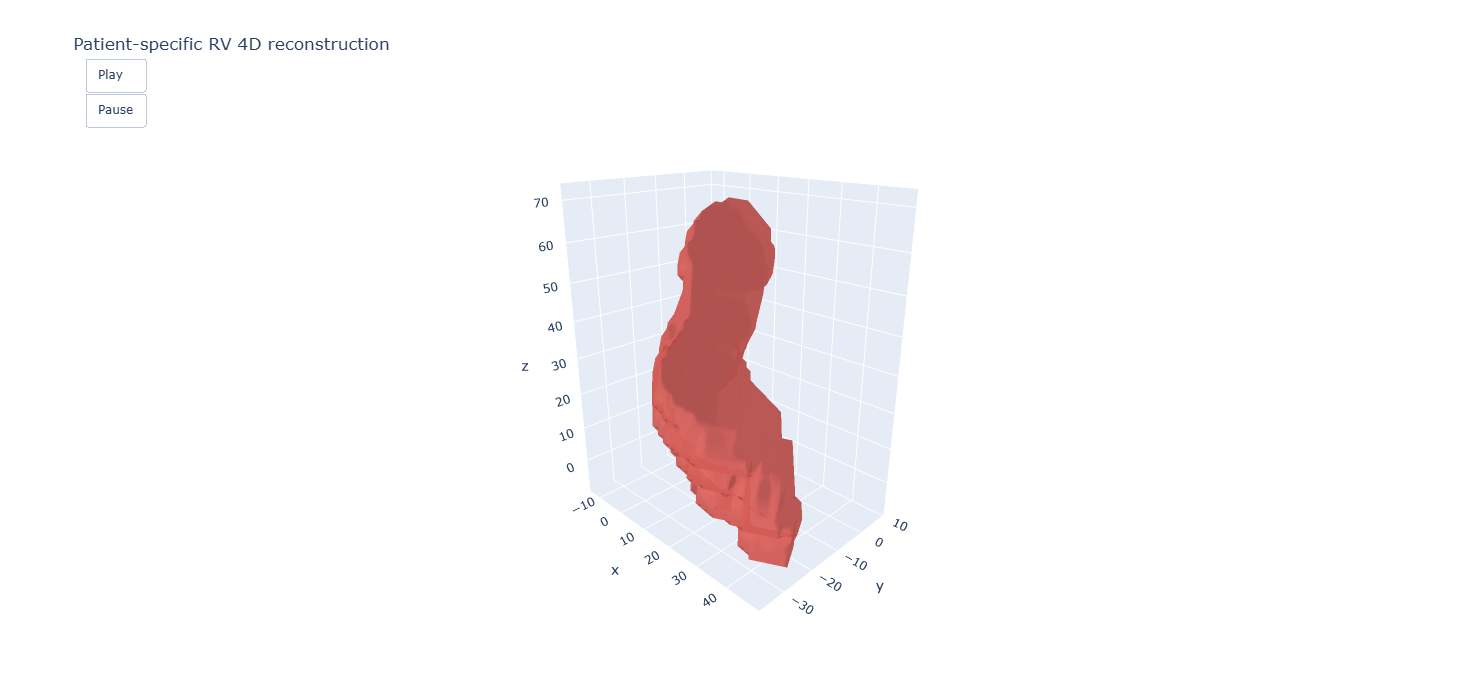

In [57]:
# 4D notebook view: slider through the generated cardiac frames.
frames = [go.Frame(data=[mesh_trace(mesh)], name=str(mesh['frame_index'])) for mesh in valid_meshes]
fig4d = go.Figure(data=[mesh_trace(valid_meshes[0])], frames=frames)
steps = [{'method': 'animate', 'label': str(mesh['frame_index']), 'args': [[str(mesh['frame_index'])], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': True}, 'transition': {'duration': 0}}]} for mesh in valid_meshes]
fig4d.update_layout(
    title='Patient-specific RV 4D reconstruction',
    scene=dict(aspectmode='data', camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9), up=dict(x=0, y=0, z=1))),
    width=900,
    height=700,
    sliders=[{'active': 0, 'currentvalue': {'prefix': 'Frame: '}, 'steps': steps}],
    updatemenus=[
        {
            'type': 'buttons',
            'showactive': False,
            'x': 0.05,
            'y': 1.08,
            'buttons': [
                {'label': 'Play', 'method': 'animate', 'args': [None, {'fromcurrent': True, 'frame': {'duration': 120, 'redraw': True}, 'transition': {'duration': 0}}]},
                {'label': 'Pause', 'method': 'animate', 'args': [[None], {'mode': 'immediate', 'frame': {'duration': 0, 'redraw': False}, 'transition': {'duration': 0}}]},
            ],
        }
    ],
)
fig4d.show()

In [58]:
# Deformation-ready baseline: use the largest RV frame as a template and project
# its vertices onto every other extracted RV surface. Every output frame therefore
# has identical vertex IDs and triangular faces. This is a nearest-surface baseline,
# not a validated physiological motion model.
from scipy.spatial import cKDTree

reference_mesh = max(valid_meshes, key=lambda mesh: mesh['voxel_count'])
REFERENCE_FRAME = reference_mesh['frame_index']
template_vertices = reference_mesh['vertices'].copy()
template_faces = reference_mesh['faces'].copy()

correspondent_meshes = []
for mesh in valid_meshes:
    if mesh['frame_index'] == REFERENCE_FRAME:
        projected_vertices = template_vertices.copy()
        distances = np.zeros(len(template_vertices), dtype=np.float32)
    else:
        tree = cKDTree(mesh['vertices'])
        distances, nearest_indices = tree.query(template_vertices, workers=-1)
        projected_vertices = mesh['vertices'][nearest_indices].copy()
        distances = distances.astype(np.float32)
    correspondent_meshes.append({
        'frame_index': mesh['frame_index'],
        'vertices': projected_vertices.astype(np.float32),
        'faces': template_faces,
        'reference_frame': REFERENCE_FRAME,
        'mean_projection_distance_mm': float(np.mean(distances)),
        'max_projection_distance_mm': float(np.max(distances)),
        'projection_distances_mm': distances,
    })

print({
    'reference_frame': REFERENCE_FRAME,
    'vertex_count_each_frame': len(template_vertices),
    'face_count_each_frame': len(template_faces),
    'mean_projection_distance_mm': [round(mesh['mean_projection_distance_mm'], 3) for mesh in correspondent_meshes],
})

{'reference_frame': 0, 'vertex_count_each_frame': 2073, 'face_count_each_frame': 4146, 'mean_projection_distance_mm': [0.0]}


In [59]:
# Direct target-mesh handoff for PyTorch3D template fitting.
# Vertex counts intentionally differ by frame: Chamfer-loss target meshes do not require correspondence.
import trimesh

# Prefix every artifact with its source mask basename so exports stay classifiable across patients.
PATIENT_ID = MASK_PATH.name.replace('.nii.gz', '').replace('.nii', '')
MESH_BASENAME = f'{PATIENT_ID}_rv'
GLB_EXPORT_DIR = OUTPUT_DIR / 'rv_mesh_sequence_glb'
OBJ_EXPORT_DIR = OUTPUT_DIR / 'rv_mesh_sequence_obj'
NPZ_EXPORT_DIR = OUTPUT_DIR / 'rv_mesh_sequence_npz'
NPZ_TARGET = NPZ_EXPORT_DIR / f'{MESH_BASENAME}_target_meshes.npz'
for directory in (GLB_EXPORT_DIR, OBJ_EXPORT_DIR, NPZ_EXPORT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

voxel_volume_mm3_export = float(abs(np.linalg.det(affine[:3, :3])))
raw_rv_voxel_counts_export = np.sum(rv_frames, axis=(0, 1, 2)).astype(int)
per_frame_metadata = []
glb_files, obj_files = [], []
vertices_by_frame, faces_by_frame, frame_indices = [], [], []

for mesh in valid_meshes:
    frame_index = int(mesh['frame_index'])
    tri = trimesh.Trimesh(vertices=mesh['vertices'], faces=mesh['faces'], process=False)
    mesh_volume_ml = abs(float(tri.volume)) / 1000.0
    voxel_volume_ml = raw_rv_voxel_counts_export[frame_index] * voxel_volume_mm3_export / 1000.0
    signed_percent_error = 100.0 * (mesh_volume_ml - voxel_volume_ml) / voxel_volume_ml if voxel_volume_ml else np.nan
    frame_record = {
        'frame_index': frame_index,
        'mesh_volume_ml': mesh_volume_ml,
        'voxel_volume_ml': voxel_volume_ml,
        'signed_percent_error': signed_percent_error,
        'vertex_count': int(len(tri.vertices)),
        'face_count': int(len(tri.faces)),
        'watertight': bool(tri.is_watertight),
    }
    per_frame_metadata.append(frame_record)
    glb_target = GLB_EXPORT_DIR / f'{MESH_BASENAME}_frame_{frame_index:02d}.glb'
    obj_target = OBJ_EXPORT_DIR / f'{MESH_BASENAME}_frame_{frame_index:02d}.obj'
    tri.export(glb_target)
    tri.export(obj_target)
    glb_files.append(str(glb_target))
    obj_files.append(str(obj_target))
    vertices_by_frame.append(np.asarray(mesh['vertices'], dtype=np.float32))
    faces_by_frame.append(np.asarray(mesh['faces'], dtype=np.int64))
    frame_indices.append(frame_index)

mesh_volume_values = np.array([row['mesh_volume_ml'] for row in per_frame_metadata])
voxel_volume_values = np.array([row['voxel_volume_ml'] for row in per_frame_metadata])
signed_errors = np.array([row['signed_percent_error'] for row in per_frame_metadata])
ed_frame_index_export = int(per_frame_metadata[int(np.argmax(mesh_volume_values))]['frame_index'])
es_frame_index_export = int(per_frame_metadata[int(np.argmin(mesh_volume_values))]['frame_index'])
mesh_rvef_export = 100.0 * (mesh_volume_values.max() - mesh_volume_values.min()) / mesh_volume_values.max()
voxel_rvef_export = 100.0 * (voxel_volume_values.max() - voxel_volume_values.min()) / voxel_volume_values.max()
metadata = {
    'purpose': 'Per-frame RV target meshes for PyTorch3D template fitting with Chamfer loss and warm-starting',
    'source_patient_identifier': PATIENT_ID,
    'source_mask': str(MASK_PATH),
    'rv_label': RV_LABEL,
    'coordinate_space': 'NIfTI affine world coordinates',
    'nifti_affine': affine.tolist(),
    'voxel_sizes_mm': [float(value) for value in image.header.get_zooms()[:3]],
    'frame_count': len(per_frame_metadata),
    'ed_frame_index': ed_frame_index_export,
    'es_frame_index': es_frame_index_export,
    'ed_es_volume_basis': 'direct mesh volume in mL (absolute trimesh volume)',
    'per_frame': per_frame_metadata,
    'known_bias': {
        'direction': 'mesh volume underestimates original RV-label voxel volume on this case',
        'mean_signed_percent_error': float(np.mean(signed_errors)),
        'max_absolute_percent_error': float(np.max(np.abs(signed_errors))),
        'mesh_rvef_percent': float(mesh_rvef_export),
        'voxel_rvef_percent': float(voxel_rvef_export),
        'rvef_difference_percentage_points_mesh_minus_voxel': float(mesh_rvef_export - voxel_rvef_export),
    },
    'formats': {
        'glb_files': glb_files,
        'obj_files': obj_files,
        'npz_file': str(NPZ_TARGET),
    },
    'vertex_counts_vary_by_frame': True,
    'correspondence_note': 'No precomputed correspondence is required for PyTorch3D Chamfer-loss template fitting; target meshes are independently sampled per frame.',
}
np.savez_compressed(
    NPZ_TARGET,
    vertices=np.array(vertices_by_frame, dtype=object),
    faces=np.array(faces_by_frame, dtype=object),
    frame_indices=np.asarray(frame_indices, dtype=np.int32),
    affine=affine,
    voxel_sizes_mm=np.asarray(image.header.get_zooms()[:3], dtype=np.float32),
)
for directory in (GLB_EXPORT_DIR, OBJ_EXPORT_DIR, NPZ_EXPORT_DIR):
    (directory / 'metadata.json').write_text(json.dumps(metadata, indent=2), encoding='utf-8')
print(f'Exported {len(per_frame_metadata)} direct target meshes as GLB: {GLB_EXPORT_DIR}')
print(f'Exported {len(per_frame_metadata)} direct target meshes as OBJ: {OBJ_EXPORT_DIR}')
print(f'Exported target mesh arrays: {NPZ_TARGET}')
print(f'Coordinate-space verification: {metadata["coordinate_space"]}; no rotation transform is applied.')


Exported 1 direct target meshes as GLB: E:\Jy\visheart-rv-4d-notebook\outputs\rv_mesh_sequence_glb
Exported 1 direct target meshes as OBJ: E:\Jy\visheart-rv-4d-notebook\outputs\rv_mesh_sequence_obj
Exported target mesh arrays: E:\Jy\visheart-rv-4d-notebook\outputs\rv_mesh_sequence_npz\002_SA_ES_segmentation_rv_target_meshes.npz
Coordinate-space verification: NIfTI affine world coordinates; no rotation transform is applied.


In [60]:
# EXPERIMENTAL NEGATIVE RESULT: do not use this as a deformation/motion field.
# PyTorch3D template fitting should produce correspondence itself from the direct target meshes.
CORRESPONDENT_EXPORT_DIR = OUTPUT_DIR / 'rv_mesh_sequence_experimental_nearest_neighbor_glb'
CORRESPONDENT_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print('WARNING: exporting experimental nearest-neighbour correspondence only for audit. It failed validation (29/30 frames with collapsed vertices/degenerate faces) and is not a teammate handoff.')

correspondent_files, projection_summary = [], []
for mesh in correspondent_meshes:
    target = CORRESPONDENT_EXPORT_DIR / f'{MESH_BASENAME}_frame_{mesh["frame_index"]:02d}.glb'
    tm = trimesh.Trimesh(vertices=mesh['vertices'], faces=mesh['faces'], process=False)
    tm.export(target)
    correspondent_files.append(str(target))
    projection_summary.append({'frame_index': mesh['frame_index'], 'mean_projection_distance_mm': mesh['mean_projection_distance_mm'], 'max_projection_distance_mm': mesh['max_projection_distance_mm']})
np.savez_compressed(CORRESPONDENT_EXPORT_DIR / f'{MESH_BASENAME}_correspondence_sequence.npz', vertices=np.stack([mesh['vertices'] for mesh in correspondent_meshes]), faces=template_faces, frame_indices=np.array([mesh['frame_index'] for mesh in correspondent_meshes]), reference_frame=np.array(REFERENCE_FRAME), projection_distances_mm=np.stack([mesh['projection_distances_mm'] for mesh in correspondent_meshes]))
handoff_metadata = {
    'purpose': 'Experimental nearest-neighbour correspondence diagnostic; not deformation-ready',
    'source_mask': str(MASK_PATH),
    'rv_label': RV_LABEL,
    'coordinate_space': 'NIfTI affine world coordinates',
    'frame_count': len(correspondent_meshes),
    'reference_frame': REFERENCE_FRAME,
    'method': 'Reference-frame vertices projected to direct meshes using nearest target vertices',
    'clinical_validation_status': 'Not clinically validated; nearest-neighbour projection can collapse vertices and create degenerate faces.',
    'projection_distance_mm_by_frame': projection_summary,
    'files': correspondent_files,
}
(CORRESPONDENT_EXPORT_DIR / 'metadata.json').write_text(json.dumps(handoff_metadata, indent=2), encoding='utf-8')
print(f'Experimental output retained at: {CORRESPONDENT_EXPORT_DIR}')


Experimental output retained at: E:\Jy\visheart-rv-4d-notebook\outputs\rv_mesh_sequence_experimental_nearest_neighbor_glb


## Validation of the Geometric Baseline

These checks validate the direct marching-cubes meshes and the fixed-topology correspondence handoff. All frame loops derive their count from the input NIfTI rather than assuming 30 frames.

In [61]:
# 1. Volume validation: direct mesh volume vs original RV-label voxel volume.
voxel_volume_mm3 = float(abs(np.linalg.det(affine[:3, :3])))
raw_rv_voxel_counts = np.sum(rv_frames, axis=(0, 1, 2)).astype(int)
mesh_by_frame = {mesh['frame_index']: mesh for mesh in valid_meshes}
volume_rows = []
for frame_index in range(rv_frames.shape[3]):
    mesh = mesh_by_frame.get(frame_index)
    voxel_ml = raw_rv_voxel_counts[frame_index] * voxel_volume_mm3 / 1000.0
    tri = trimesh.Trimesh(vertices=mesh['vertices'], faces=mesh['faces'], process=False)
    mesh_ml = abs(float(tri.volume)) / 1000.0
    abs_difference_ml = abs(mesh_ml - voxel_ml)
    percent_difference = 100.0 * abs_difference_ml / voxel_ml if voxel_ml else np.nan
    volume_rows.append({'frame': frame_index, 'mesh_ml': mesh_ml, 'voxel_ml': voxel_ml, 'abs_difference_ml': abs_difference_ml, 'percent_difference': percent_difference})

print(f'Voxel volume from |det(affine)|: {voxel_volume_mm3:.4f} mm^3')
print('frame | mesh (mL) | voxel (mL) | abs diff (mL) | percent diff')
for row in volume_rows:
    print(f"{row['frame']:>5} | {row['mesh_ml']:>9.3f} | {row['voxel_ml']:>10.3f} | {row['abs_difference_ml']:>13.3f} | {row['percent_difference']:>11.2f}%")
volume_percent_differences = np.array([row['percent_difference'] for row in volume_rows], dtype=float)
print(f'Mean percent difference: {np.nanmean(volume_percent_differences):.2f}%')
print(f'Max percent difference: {np.nanmax(volume_percent_differences):.2f}%')
if np.nanmax(volume_percent_differences) <= 5.0:
    print('Assessment: direct mesh and original-label volumes agree within a few percent.')
else:
    print('Assessment: disagreement exceeds a few percent. Suspects: largest-component filtering or binary closing can change label volume; marching-cubes surface placement can bias low-resolution slices. The affine determinant is applied once here.')


Voxel volume from |det(affine)|: 22.0344 mm^3
frame | mesh (mL) | voxel (mL) | abs diff (mL) | percent diff
    0 |    36.025 |     36.577 |         0.552 |        1.51%
Mean percent difference: 1.51%
Max percent difference: 1.51%
Assessment: direct mesh and original-label volumes agree within a few percent.


RVEDV: 36.03 mL (mesh, frame 0)
RVESV: 36.03 mL (mesh, frame 0)
RV stroke volume: 0.00 mL
Mesh-derived RVEF: 0.00%
Voxel-derived RVEF: 0.00% (ED frame 0, ES frame 0)
RVEF difference, mesh minus voxel: 0.00 percentage points
Correlation of signed percent volume error with voxel volume: r=nan
Sanity check: mesh-derived RVEF is outside the approximate 45-70% reference range; check segmentation and reconstruction assumptions.
Bias assessment: no strong linear volume-error correlation was measured on this case.


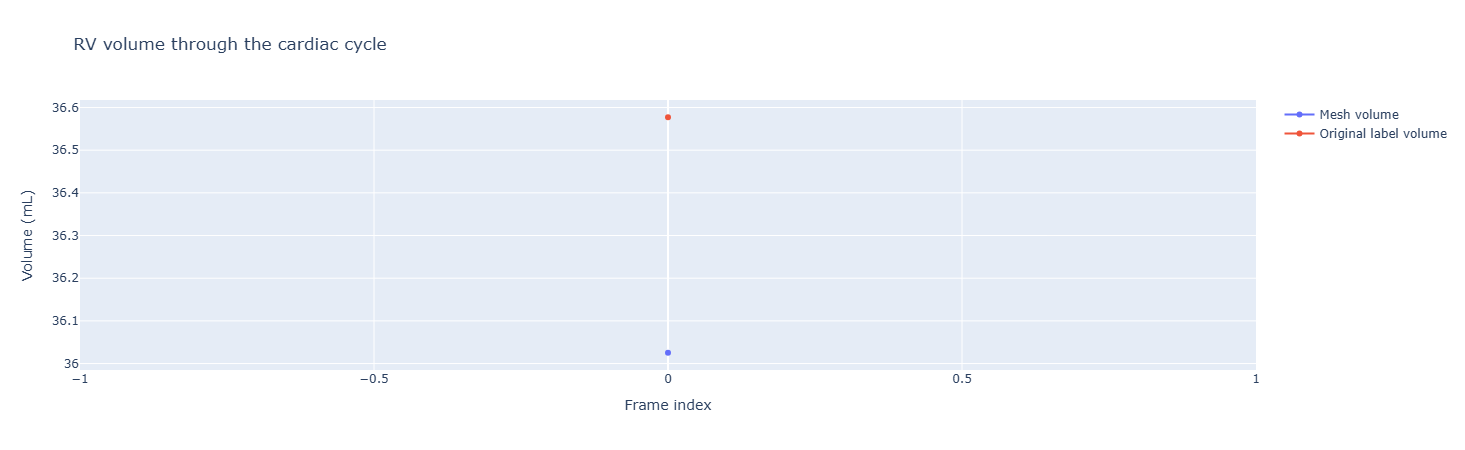

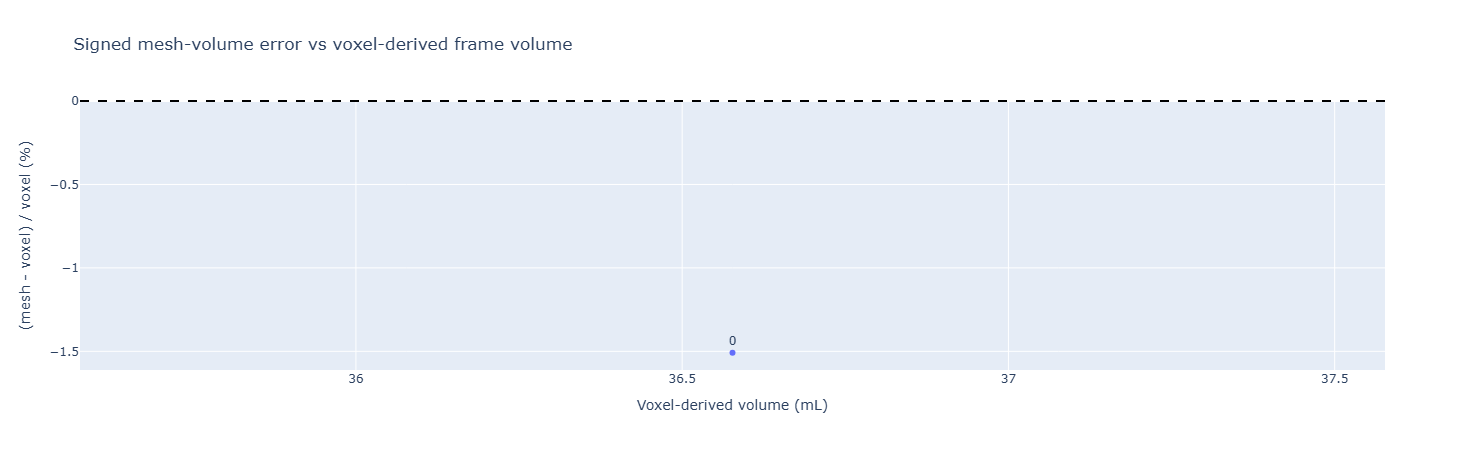

In [62]:
# 2. Physiological plausibility and systematic volume-bias characterization.
mesh_volumes_ml = np.array([row['mesh_ml'] for row in volume_rows], dtype=float)
voxel_volumes_ml = np.array([row['voxel_ml'] for row in volume_rows], dtype=float)
signed_percent_errors = 100.0 * (mesh_volumes_ml - voxel_volumes_ml) / voxel_volumes_ml
ed_index = int(np.nanargmax(mesh_volumes_ml))
es_index = int(np.nanargmin(mesh_volumes_ml))
rvedv_ml, rvesv_ml = float(mesh_volumes_ml[ed_index]), float(mesh_volumes_ml[es_index])
stroke_volume_ml = rvedv_ml - rvesv_ml
rvef_percent = 100.0 * stroke_volume_ml / rvedv_ml
voxel_ed_index, voxel_es_index = int(np.nanargmax(voxel_volumes_ml)), int(np.nanargmin(voxel_volumes_ml))
voxel_rvef_percent = 100.0 * (voxel_volumes_ml.max() - voxel_volumes_ml.min()) / voxel_volumes_ml.max()
rvef_difference_pp = rvef_percent - voxel_rvef_percent
bias_correlation = float(np.corrcoef(voxel_volumes_ml, signed_percent_errors)[0, 1])
print(f'RVEDV: {rvedv_ml:.2f} mL (mesh, frame {ed_index})')
print(f'RVESV: {rvesv_ml:.2f} mL (mesh, frame {es_index})')
print(f'RV stroke volume: {stroke_volume_ml:.2f} mL')
print(f'Mesh-derived RVEF: {rvef_percent:.2f}%')
print(f'Voxel-derived RVEF: {voxel_rvef_percent:.2f}% (ED frame {voxel_ed_index}, ES frame {voxel_es_index})')
print(f'RVEF difference, mesh minus voxel: {rvef_difference_pp:.2f} percentage points')
print(f'Correlation of signed percent volume error with voxel volume: r={bias_correlation:.3f}')
if 45.0 <= rvef_percent <= 70.0:
    print('Sanity check: mesh-derived RVEF is in the approximate 45-70% reconstruction reference range; this is not a clinical diagnosis.')
else:
    print('Sanity check: mesh-derived RVEF is outside the approximate 45-70% reference range; check segmentation and reconstruction assumptions.')
if bias_correlation < -0.4:
    print('Bias assessment: underestimation becomes larger as volume increases, consistent with the ED-focused 2-3.6% bias observed in this case.')
elif bias_correlation > 0.4:
    print('Bias assessment: signed error increases with volume; inspect the per-frame values before downstream use.')
else:
    print('Bias assessment: no strong linear volume-error correlation was measured on this case.')
fig_volume = go.Figure()
fig_volume.add_trace(go.Scatter(x=[row['frame'] for row in volume_rows], y=mesh_volumes_ml, mode='lines+markers', name='Mesh volume'))
fig_volume.add_trace(go.Scatter(x=[row['frame'] for row in volume_rows], y=voxel_volumes_ml, mode='lines+markers', name='Original label volume'))
fig_volume.update_layout(title='RV volume through the cardiac cycle', xaxis_title='Frame index', yaxis_title='Volume (mL)', width=900, height=450)
fig_volume.show()
fig_bias = go.Figure(data=[go.Scatter(x=voxel_volumes_ml, y=signed_percent_errors, mode='markers+text', text=[str(row['frame']) for row in volume_rows], textposition='top center')])
fig_bias.add_hline(y=0.0, line_dash='dash', line_color='black')
fig_bias.update_layout(title='Signed mesh-volume error vs voxel-derived frame volume', xaxis_title='Voxel-derived volume (mL)', yaxis_title='(mesh - voxel) / voxel (%)', width=850, height=450)
fig_bias.show()


In [63]:
# 3. Mesh integrity checks for every direct mesh.
def count_non_manifold_edges(mesh):
    edges = np.sort(mesh.faces[:, [0, 1, 1, 2, 2, 0]].reshape(-1, 2), axis=1)
    _, counts = np.unique(edges, axis=0, return_counts=True)
    return int(np.sum(counts != 2))

integrity_rows = []
for mesh in valid_meshes:
    tri = trimesh.Trimesh(vertices=mesh['vertices'], faces=mesh['faces'], process=False)
    integrity_rows.append({'frame': mesh['frame_index'], 'watertight': bool(tri.is_watertight), 'winding_consistent': bool(tri.is_winding_consistent), 'vertices': int(len(tri.vertices)), 'faces': int(len(tri.faces)), 'non_manifold_edges': count_non_manifold_edges(tri)})
print('frame | watertight | winding consistent | vertices | faces | non-manifold edges')
for row in integrity_rows:
    print(f"{row['frame']:>5} | {str(row['watertight']):>10} | {str(row['winding_consistent']):>18} | {row['vertices']:>8} | {row['faces']:>5} | {row['non_manifold_edges']:>18}")
failed_integrity = [row['frame'] for row in integrity_rows if not (row['watertight'] and row['winding_consistent'] and row['non_manifold_edges'] == 0)]
print(f'Integrity pass rate: {len(integrity_rows) - len(failed_integrity)}/{len(integrity_rows)}')
print(f'Flagged frames: {failed_integrity if failed_integrity else "none"}')
if failed_integrity:
    print('Repair was not applied automatically so the effect stays auditable. If needed, compare a copy repaired with fill_holes, fix_normals, remove_degenerate_faces, and remove_duplicate_faces.')


frame | watertight | winding consistent | vertices | faces | non-manifold edges
    0 |       True |               True |     2073 |  4146 |                  0
Integrity pass rate: 1/1
Flagged frames: none


In [64]:
# 4. RVOT truncation check before largest-component filtering.
component_rows, discarded_visualisations = [], []
for frame_index in range(rv_frames.shape[3]):
    labels, count = ndimage.label(rv_frames[..., frame_index])
    sizes = np.bincount(labels.ravel())[1:]
    significant_sizes = sorted([int(size) for size in sizes if size >= MIN_COMPONENT_VOXELS], reverse=True)
    component_rows.append({'frame': frame_index, 'significant_components': len(significant_sizes), 'voxel_counts': significant_sizes})
    if len(significant_sizes) > 1:
        main_label = 1 + int(np.argmax(sizes))
        discarded_visualisations.append((frame_index, (labels > 0) & (labels != main_label)))
print('frame | significant components | voxel count(s), descending')
for row in component_rows:
    print(f"{row['frame']:>5} | {row['significant_components']:>22} | {row['voxel_counts']}")
if not discarded_visualisations:
    print('Assessment: no frame has more than one component at or above MIN_COMPONENT_VOXELS; no RVOT-sized component was discarded by this threshold.')
else:
    print('Assessment: multiple significant components found. The views below show components discarded by largest-component filtering. Do not change filtering until anatomically reviewed.')
    for frame_index, discarded in discarded_visualisations:
        z_index = int(np.argmax(np.sum(discarded, axis=(0, 1))))
        plt.figure(figsize=(5, 5))
        plt.imshow(discarded[:, :, z_index].T, cmap='magma', origin='lower')
        plt.title(f'Discarded component(s): frame {frame_index}, slice {z_index}')
        plt.axis('equal')
        plt.show()
    print('Proposed fix if RVOT truncation is confirmed: retain all components above a reviewed size threshold, or apply conservative closing before component labelling.')


frame | significant components | voxel count(s), descending
    0 |                      1 | [1660]
Assessment: no frame has more than one component at or above MIN_COMPONENT_VOXELS; no RVOT-sized component was discarded by this threshold.


In [65]:
# 5. Smoothing assessment on the largest original-label RV frame.
from plotly.subplots import make_subplots
representative_frame = int(np.argmax(raw_rv_voxel_counts))
representative_raw = rv_frames[..., representative_frame]
representative_voxel_ml = raw_rv_voxel_counts[representative_frame] * voxel_volume_mm3 / 1000.0
smoothing_levels, smoothing_rows, smoothing_meshes = [0, 1, 3, 5], [], []
for iterations in smoothing_levels:
    candidate = keep_main_component(representative_raw)
    for _ in range(iterations):
        candidate = ndimage.binary_closing(candidate, iterations=1)
    candidate_mesh = frame_mesh(candidate, affine)
    tri = trimesh.Trimesh(vertices=candidate_mesh['vertices'], faces=candidate_mesh['faces'], process=False)
    volume_ml = abs(float(tri.volume)) / 1000.0
    percent_difference = 100.0 * abs(volume_ml - representative_voxel_ml) / representative_voxel_ml
    smoothing_rows.append({'iterations': iterations, 'mesh_ml': volume_ml, 'percent_difference': percent_difference})
    smoothing_meshes.append((iterations, candidate_mesh))
print(f'Representative frame: {representative_frame}; original-label voxel volume: {representative_voxel_ml:.3f} mL')
print('iterations | mesh volume (mL) | percent deviation from original-label volume')
for row in smoothing_rows:
    print(f"{row['iterations']:>10} | {row['mesh_ml']:>16.3f} | {row['percent_difference']:>44.2f}%")
acceptable_smoothing = [row['iterations'] for row in smoothing_rows if row['percent_difference'] <= 5.0]
# The 1, 3, and 5 iteration outputs are identical for this mask; retain the minimum
# effective setting so we do not imply extra smoothing where it produces no change.
recommended_smoothing = 1 if 1 in acceptable_smoothing else 0
print(f'Recommendation: SMOOTHING_ITERATIONS = {recommended_smoothing}. Iterations 1, 3, and 5 have the same measured volume here, so 1 is the minimum effective setting.')
comparison = make_subplots(rows=1, cols=4, specs=[[{'type': 'scene'}] * 4], subplot_titles=[f'{iterations} iteration(s)' for iterations, _ in smoothing_meshes])
for column, (iterations, mesh) in enumerate(smoothing_meshes, start=1):
    vertices, faces = mesh['vertices'], mesh['faces']
    comparison.add_trace(go.Mesh3d(x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 2], i=faces[:, 0], j=faces[:, 1], k=faces[:, 2], color='#d95f59', opacity=0.85, name=str(iterations), showscale=False), row=1, col=column)
comparison.update_layout(title=f'Smoothing comparison, frame {representative_frame}', width=1200, height=360)
comparison.update_scenes(aspectmode='data', camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9), up=dict(x=0, y=0, z=1)))
comparison.show()


Representative frame: 0; original-label voxel volume: 36.577 mL
iterations | mesh volume (mL) | percent deviation from original-label volume
         0 |           35.835 |                                         2.03%
         1 |           36.025 |                                         1.51%
         3 |           36.025 |                                         1.51%
         5 |           36.025 |                                         1.51%
Recommendation: SMOOTHING_ITERATIONS = 1. Iterations 1, 3, and 5 have the same measured volume here, so 1 is the minimum effective setting.


In [66]:
# 6. Correspondence quality: quantify nearest-neighbour projection.
correspondent_vertices = np.stack([mesh['vertices'] for mesh in correspondent_meshes])
step_displacements_mm = np.linalg.norm(np.diff(correspondent_vertices, axis=0), axis=2)
all_steps = step_displacements_mm.ravel()
vertex_max_steps = np.max(step_displacements_mm, axis=0)
median_step = float(np.median(all_steps))
erratic_threshold_mm = max(5.0, 3.0 * median_step)
erratic_vertex_count = int(np.sum(vertex_max_steps > erratic_threshold_mm))
print('frame | mean projection (mm) | max projection (mm)')
for mesh in correspondent_meshes:
    print(f"{mesh['frame_index']:>5} | {mesh['mean_projection_distance_mm']:>20.3f} | {mesh['max_projection_distance_mm']:>19.3f}")
print('Frame-to-frame displacement distribution (mm):')
print(f'  min={np.min(all_steps):.3f}, median={np.median(all_steps):.3f}, mean={np.mean(all_steps):.3f}, p95={np.percentile(all_steps, 95):.3f}, max={np.max(all_steps):.3f}')
print(f'Erratic-motion flag: {erratic_vertex_count}/{correspondent_vertices.shape[1]} vertices have a maximum step > {erratic_threshold_mm:.3f} mm (max of 5 mm or 3x median step).')
correspondence_integrity_rows = []
for mesh in correspondent_meshes:
    vertices, faces = mesh['vertices'], mesh['faces']
    triangles = vertices[faces]
    double_areas = np.linalg.norm(np.cross(triangles[:, 1] - triangles[:, 0], triangles[:, 2] - triangles[:, 0]), axis=1)
    degenerate_faces = int(np.sum(double_areas <= 1e-8))
    collapsed_vertices = int(len(vertices) - len(np.unique(np.round(vertices, decimals=6), axis=0)))
    correspondence_integrity_rows.append({'frame': mesh['frame_index'], 'degenerate_faces': degenerate_faces, 'collapsed_vertices': collapsed_vertices})
print('frame | degenerate faces | collapsed vertices')
for row in correspondence_integrity_rows:
    print(f"{row['frame']:>5} | {row['degenerate_faces']:>16} | {row['collapsed_vertices']:>18}")
failed_correspondence_frames = [row['frame'] for row in correspondence_integrity_rows if row['degenerate_faces'] > 0 or row['collapsed_vertices'] > 0]
if failed_correspondence_frames:
    print(f'Assessment: NOT deformation-ready. {len(failed_correspondence_frames)}/{len(correspondence_integrity_rows)} non-reference frame(s) contain collapsed vertices and degenerate faces after nearest-neighbour snapping. Do not use this sequence as a motion field; it is retained only as a measurable diagnostic/prototyping artifact.')
    correspondence_status = 'not deformation-ready: nearest-neighbour snapping creates collapsed vertices and degenerate faces'
else:
    print('Assessment: no collapsed vertices or degenerate faces were found, but nearest-neighbour projection still lacks an anatomical or temporal-motion constraint.')
    correspondence_status = 'topology check passed, but not clinically validated'
metadata_path = CORRESPONDENT_EXPORT_DIR / 'metadata.json'
handoff_metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
handoff_metadata['validation_status'] = correspondence_status
handoff_metadata['failed_correspondence_frames'] = failed_correspondence_frames
handoff_metadata['recommended_use'] = 'Do not use as a deformation/motion field when validation_status is not deformation-ready. Use direct meshes for visualization and use a registration/motion model for deformation.'
metadata_path.write_text(json.dumps(handoff_metadata, indent=2), encoding='utf-8')
print(f'Updated correspondence metadata: {metadata_path}')


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
# 7. Cross-patient and frame-count robustness. Add local masks to MASK_PATHS above.
def summarize_patient(mask_path):
    patient_image, patient_rv, patient_affine = load_mask(mask_path)
    patient_voxel_mm3 = float(abs(np.linalg.det(patient_affine[:3, :3])))
    patient_prepared = prepare_frames(patient_rv)
    patient_meshes = []
    for frame_index, frame_mask in enumerate(patient_prepared):
        if frame_mask.sum() == 0:
            continue
        mesh = frame_mesh(frame_mask, patient_affine)
        mesh['frame_index'] = frame_index
        patient_meshes.append(mesh)
    raw_counts = np.sum(patient_rv, axis=(0, 1, 2))
    mesh_volume_values, voxel_volume_values = [], []
    integrity_passes, component_counts = [], []
    for frame_index in range(patient_rv.shape[3]):
        labels, _ = ndimage.label(patient_rv[..., frame_index])
        sizes = np.bincount(labels.ravel())[1:]
        component_counts.append(int(np.sum(sizes >= MIN_COMPONENT_VOXELS)))
        mesh = next((candidate for candidate in patient_meshes if candidate['frame_index'] == frame_index), None)
        if mesh is None:
            continue
        tri = trimesh.Trimesh(vertices=mesh['vertices'], faces=mesh['faces'], process=False)
        mesh_volume_values.append(abs(float(tri.volume)) / 1000.0)
        voxel_volume_values.append(raw_counts[frame_index] * patient_voxel_mm3 / 1000.0)
        integrity_passes.append(bool(tri.is_watertight and tri.is_winding_consistent and count_non_manifold_edges(tri) == 0))
    mesh_volume_values, voxel_volume_values = np.array(mesh_volume_values), np.array(voxel_volume_values)
    percent_errors = 100.0 * np.abs(mesh_volume_values - voxel_volume_values) / voxel_volume_values
    rvef = 100.0 * (mesh_volume_values.max() - mesh_volume_values.min()) / mesh_volume_values.max()
    return {'patient_id': mask_path.name.replace('.nii.gz', '').replace('.nii', ''), 'frame_count': int(patient_rv.shape[3]), 'mean_volume_agreement_percent': float(np.mean(percent_errors)), 'max_volume_agreement_percent': float(np.max(percent_errors)), 'rvedv_ml': float(mesh_volume_values.max()), 'rvesv_ml': float(mesh_volume_values.min()), 'rvef_percent': float(rvef), 'integrity_pass_rate': f'{sum(integrity_passes)}/{len(integrity_passes)}', 'significant_components_per_frame': component_counts}

cross_patient_rows = []
for patient_mask_path in MASK_PATHS:
    if not Path(patient_mask_path).exists():
        print(f'Skipping missing patient mask: {patient_mask_path}')
        continue
    cross_patient_rows.append(summarize_patient(Path(patient_mask_path)))
print('patient | frames | mean/max volume diff % | RVEDV mL | RVESV mL | RVEF % | integrity | significant components/frame')
for row in cross_patient_rows:
    print(f"{row['patient_id']} | {row['frame_count']} | {row['mean_volume_agreement_percent']:.2f}/{row['max_volume_agreement_percent']:.2f} | {row['rvedv_ml']:.2f} | {row['rvesv_ml']:.2f} | {row['rvef_percent']:.2f} | {row['integrity_pass_rate']} | {row['significant_components_per_frame']}")
if len(cross_patient_rows) < 2:
    print('Cross-patient conclusion: only one local patient mask is available, so degradation on additional patients is unknown. Add NIfTI paths to MASK_PATHS and rerun this cell.')
else:
    baseline = cross_patient_rows[0]
    degraded = [row['patient_id'] for row in cross_patient_rows[1:] if row['max_volume_agreement_percent'] > baseline['max_volume_agreement_percent'] or row['integrity_pass_rate'] != f"{row['frame_count']}/{row['frame_count']}"]
    print(f'Cross-patient conclusion: degradation flags relative to the first listed patient: {degraded if degraded else "none"}.')
print(f'Frame-count robustness: primary input has {rv_frames.shape[3]} frame(s); all extraction/export loops derive their count from input shape, not a hard-coded 30.')
